<a href="https://colab.research.google.com/github/RYU-MCFLY/2026-NLP-LLMs-with-chatgpt/blob/main/2026-O1_IntegratedGradientDescents_MEJORADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicabilidad Contrastiva Global con Integrated Gradients — Implementación desde Cero

## Arquitectura matemática

Este notebook implementa **Integrated Gradients (IG)** de forma completamente manual — sin Captum — con las siguientes mejoras críticas:

1. **Trayectoria discreta explícita**: la integral se aproxima como suma de Riemann sobre `m+1` puntos interpolados en el espacio latente.
2. **Baseline semántico reconstruido**: en lugar de ceros puros (que colapsan la morfología posicional de DistilBERT), el baseline incorpora el embedding posicional para que la trayectoria α ∈ [0,1] empiece desde un estado lingüísticamente neutro.
3. **Alineación de tensores garantizada**: todos los tensores en la trayectoria tienen shape `(m+1, 1, seq_len, 768)` y se verifican antes de cada operación.
4. **Reconstrucción morfológica**: los pesos IG se reagrupan por morfemas sub-word, se normalizan y se traducen a un diagnóstico legible en lenguaje natural.
5. **Explicabilidad contrastiva global**: se analizan múltiples reseñas del dataset `datos_financial_reviews.json` y se construye un mapa global de términos causales.

**Fórmula central:**
$$IG_i(x) = (x_i - x'_i) \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i}\, d\alpha \approx (x_i - x'_i) \times \frac{1}{m}\sum_{k=1}^{m} \nabla_{x_i} F\!\left(x' + \frac{k}{m}(x - x')\right)$$

**Propiedad de completitud:** $\sum_i IG_i(x) = F(x) - F(x')$

## 0. Dependencias e imports

In [1]:
# Instalar dependencias (descomenta si es necesario)
# !pip install transformers torch matplotlib seaborn pandas tqdm

import json
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from IPython.display import display, HTML

import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('coolwarm')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Dispositivo activo: {DEVICE}')
print(f'✓ PyTorch {torch.__version__}')

✓ Dispositivo activo: cpu
✓ PyTorch 2.10.0+cpu


## 1. Dataset — `datos_financial_reviews.json`

El archivo debe tener la estructura:
```json
[
  {"id": 1, "text": "...", "label": "POSITIVE" | "NEGATIVE", "categoria": "..."},
  ...
]
```
Si el archivo no existe en disco, el notebook genera un dataset sintético de reseñas financieras para no interrumpir el flujo.

In [3]:
# ─────────────────────────────────────────────────────────────
# Carga del dataset o generación sintética de respaldo
# ─────────────────────────────────────────────────────────────

DATASET_PATH = 'datos_financial_reviews.json'

SYNTHETIC_REVIEWS = [
    {"id": 1,  "text": "The investment product delivered exceptional returns this quarter and exceeded all expectations.",
     "label": "POSITIVE", "categoria": "inversiones"},
    {"id": 2,  "text": "This financial service completely failed to deliver on its promises and caused significant losses.",
     "label": "NEGATIVE", "categoria": "servicios"},
    {"id": 3,  "text": "The portfolio management fees are unreasonably high and the returns are consistently disappointing.",
     "label": "NEGATIVE", "categoria": "portafolio"},
    {"id": 4,  "text": "Outstanding customer support and transparent fee structure made this a truly rewarding experience.",
     "label": "POSITIVE", "categoria": "atencion"},
    {"id": 5,  "text": "The dividend yield was extremely poor and the stock valuation appears completely overpriced.",
     "label": "NEGATIVE", "categoria": "acciones"},
    {"id": 6,  "text": "Incredible growth in my retirement fund thanks to their brilliant diversification strategy.",
     "label": "POSITIVE", "categoria": "pensiones"},
    {"id": 7,  "text": "Hidden fees and misleading performance reports destroyed my trust in this brokerage firm.",
     "label": "NEGATIVE", "categoria": "broker"},
    {"id": 8,  "text": "The ETF selection is fantastic and the low expense ratios make it a superior long-term choice.",
     "label": "POSITIVE", "categoria": "etf"},
    {"id": 9,  "text": "The risk assessment was wrong, the leverage was excessive and ultimately wiped out our capital.",
     "label": "NEGATIVE", "categoria": "riesgo"},
    {"id": 10, "text": "Brilliant advisory team with deep market expertise and consistently strong performance record.",
     "label": "POSITIVE", "categoria": "asesoria"},
]

try:
    with open(DATASET_PATH, 'r', encoding='utf-8') as f:
        reviews = json.load(f)
    print(f'✓ Dataset cargado desde {DATASET_PATH}: {len(reviews)} registros')
except (FileNotFoundError, json.JSONDecodeError): # Modified to catch JSONDecodeError
    # Escribir el sintético al disco para persistencia
    reviews = SYNTHETIC_REVIEWS
    with open(DATASET_PATH, 'w', encoding='utf-8') as f:
        json.dump(reviews, f, ensure_ascii=False, indent=2)
    print(f'⚠ Archivo no encontrado o corrupto. Creado dataset sintético con {len(reviews)} reseñas financieras.')
    print(f'  → Guardado en: {DATASET_PATH}')

df_reviews = pd.DataFrame(reviews)
print(f'\nDistribución de clases:')
display(df_reviews['label'].value_counts().to_frame())
display(df_reviews[['id', 'label', 'text']].head(5))

⚠ Archivo no encontrado o corrupto. Creado dataset sintético con 10 reseñas financieras.
  → Guardado en: datos_financial_reviews.json

Distribución de clases:


,count
label,
POSITIVE,5
NEGATIVE,5


,id,label,text
0,1,POSITIVE,The investment product delivered exceptional r...
1,2,NEGATIVE,This financial service completely failed to de...
2,3,NEGATIVE,The portfolio management fees are unreasonably...
3,4,POSITIVE,Outstanding customer support and transparent f...
4,5,NEGATIVE,The dividend yield was extremely poor and the ...


## 2. Carga del modelo

In [4]:
MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'

t0 = time.perf_counter()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(DEVICE).eval()
print(f'✓ Modelo cargado en {time.perf_counter()-t0:.1f}s')
print(f'  Clases: {model.config.id2label}')
print(f'  Embedding dim: {model.config.hidden_size}')
print(f'  Vocab size:    {model.config.vocab_size}')

# Capa de embeddings (acceso directo para la trayectoria)
EMB_LAYER = model.get_input_embeddings()
EMB_DIM   = model.config.hidden_size  # 768 para DistilBERT

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ Modelo cargado en 7.6s
  Clases: {0: 'NEGATIVE', 1: 'POSITIVE'}
  Embedding dim: 768
  Vocab size:    30522


## 3. Construcción del Baseline Semántico

### ¿Por qué no usar ceros puros?

DistilBERT suma tres embeddings: **word + position + token_type**. Un baseline de ceros puro ignora el embedding posicional, provocando que el punto `α=0` de la trayectoria no sea un estado lingüístico coherente.

La estrategia correcta: el baseline mantiene **posición y token_type** intactos, pero usa el **token [PAD] (id=0)** para la componente léxica. Esto garantiza:
- Shape idéntico al input real: `(1, seq_len, 768)` ✓
- Punto de partida morfológicamente neutro ✓  
- Trayectoria continua en el espacio latente ✓

In [5]:
def construir_baseline_semantico(input_ids: torch.Tensor,
                                  attention_mask: torch.Tensor,
                                  modelo) -> torch.Tensor:
    """
    Reconstruye el baseline morfológico.

    Reemplaza la componente léxica por el token PAD (id=0)
    pero preserva la geometría posicional del espacio latente.

    Args:
        input_ids     : (1, seq_len)   — ids del texto real
        attention_mask: (1, seq_len)   — máscara de atención
        modelo        : modelo HF

    Returns:
        baseline_emb  : (1, seq_len, 768)  — baseline con morfología posicional
        input_emb     : (1, seq_len, 768)  — embeddings reales
    """
    seq_len = input_ids.shape[1]
    emb_layer = modelo.get_input_embeddings()

    # Embeddings del texto real
    with torch.no_grad():
        input_emb = emb_layer(input_ids)  # (1, seq_len, 768)

    # Baseline: token PAD para todos los tokens (cero semántico)
    pad_ids      = torch.zeros_like(input_ids)          # todos PAD
    with torch.no_grad():
        baseline_word = emb_layer(pad_ids)              # (1, seq_len, 768)

    # Obtener embeddings posicionales del modelo DistilBERT
    # para añadirlos al baseline y mantener la morfología espacial
    try:
        pos_layer = modelo.distilbert.embeddings.position_embeddings
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)  # (1, seq_len)
        with torch.no_grad():
            pos_emb = pos_layer(positions)  # (1, seq_len, 768)
        baseline_emb = baseline_word + pos_emb  # morfología posicional intacta
    except AttributeError:
        # Fallback para otros modelos sin posición explícita
        baseline_emb = baseline_word

    # Verificación de shapes — crítico para la trayectoria
    assert input_emb.shape == baseline_emb.shape, (
        f"Shape mismatch: input={input_emb.shape}, baseline={baseline_emb.shape}"
    )

    return baseline_emb.detach(), input_emb.detach()


# ── Test de verificación con la primera reseña ──────────────────────
test_txt     = reviews[0]['text']
test_inputs  = tokenizer(test_txt, return_tensors='pt', truncation=True, max_length=128)
test_ids     = test_inputs['input_ids'].to(DEVICE)
test_mask    = test_inputs['attention_mask'].to(DEVICE)

base_emb, inp_emb = construir_baseline_semantico(test_ids, test_mask, model)
print(f'✓ Shape input_emb    : {tuple(inp_emb.shape)}')
print(f'✓ Shape baseline_emb : {tuple(base_emb.shape)}')
print(f'✓ Shapes idénticos   : {inp_emb.shape == base_emb.shape}')
print(f'✓ Norma input[0,0]   : {inp_emb[0,0].norm():.4f}')
print(f'✓ Norma baseline[0,0]: {base_emb[0,0].norm():.4f}')

✓ Shape input_emb    : (1, 15, 768)
✓ Shape baseline_emb : (1, 15, 768)
✓ Shapes idénticos   : True
✓ Norma input[0,0]   : 2.1875
✓ Norma baseline[0,0]: 2.6759


## 4. Trayectoria Discreta — Integral de Riemann en el Espacio Latente

### Algoritmo matemático

Construimos **m+1 puntos de interpolación** en el espacio de embeddings:

$$\hat{x}^{(k)} = x' + \frac{k}{m}\,(x - x'), \quad k = 0, 1, \ldots, m$$

Para cada punto calculamos el gradiente $\nabla_{\hat{x}} F(\hat{x}^{(k)})$ y aproximamos la integral:

$$IG_i \approx (x_i - x'_i) \cdot \frac{1}{m} \sum_{k=1}^{m} \frac{\partial F}{\partial x_i}\bigg|_{\hat{x}^{(k)}}$$

**Control de tensores:**
- Cada punto de la trayectoria: `(1, seq_len, 768)`
- Stack completo: `(m+1, 1, seq_len, 768)`
- Gradiente promedio: `(1, seq_len, 768)`
- IG final: `(1, seq_len, 768)` — mismas dimensiones que los embeddings

In [6]:
def calcular_trayectoria_ig(
    texto: str,
    clase_objetivo: int,
    modelo,
    tokenizador,
    m_steps: int = 100,
    max_length: int = 128,
    debug: bool = False
) -> dict:
    """
    Integrated Gradients implementado a mano con verificación de tensores.

    Calcula la trayectoria completa en el espacio latente y devuelve
    atribuciones por token con metadatos de diagnóstico.

    Args:
        texto          : texto de entrada
        clase_objetivo : índice de clase (0=NEGATIVE, 1=POSITIVE)
        modelo         : modelo HF
        tokenizador    : tokenizer HF
        m_steps        : número de pasos de la integral de Riemann
        max_length     : longitud máxima de tokenización
        debug          : imprime shapes intermedios

    Returns:
        dict con tokens, atribuciones, delta de completitud y trayectoria
    """
    # ──────────────────────────────────────────────────
    # PASO 1: Tokenización y preparación de tensores
    # ──────────────────────────────────────────────────
    enc = tokenizador(
        texto, return_tensors='pt',
        truncation=True, max_length=max_length
    )
    input_ids     = enc['input_ids'].to(DEVICE)       # (1, seq_len)
    attention_mask= enc['attention_mask'].to(DEVICE)   # (1, seq_len)
    tokens        = tokenizador.convert_ids_to_tokens(input_ids[0])
    seq_len       = input_ids.shape[1]

    # ──────────────────────────────────────────────────
    # PASO 2: Baseline morfológico + embeddings reales
    # ──────────────────────────────────────────────────
    baseline_emb, input_emb = construir_baseline_semantico(
        input_ids, attention_mask, modelo
    )
    # Ambos: (1, seq_len, 768)
    delta_emb = input_emb - baseline_emb  # (1, seq_len, 768)

    if debug:
        print('═' * 60)
        print(f'  TRAYECTORIA IG — {m_steps} pasos de Riemann')
        print(f'  Texto       : {texto[:70]}...' if len(texto) > 70 else f'  Texto       : {texto}')
        print(f'  Clase obj.  : {clase_objetivo} → {modelo.config.id2label[clase_objetivo]}')
        print(f'  seq_len     : {seq_len}')
        print(f'  input_emb   : {tuple(input_emb.shape)}')
        print(f'  baseline_emb: {tuple(baseline_emb.shape)}')
        print(f'  delta_emb   : {tuple(delta_emb.shape)}')
        print('─' * 60)

    # ──────────────────────────────────────────────────
    # PASO 3: Construcción explícita de la trayectoria
    #         α_k = k/m, k = 0..m → m+1 puntos
    # ──────────────────────────────────────────────────
    gradientes = []   # lista de tensores (1, seq_len, 768)
    scores_trayectoria = []  # F(x̂_k) para visualización

    for k in range(m_steps + 1):
        alpha = k / m_steps

        # Punto interpolado en el espacio latente
        # x̂(α) = x' + α·(x - x')  →  shape: (1, seq_len, 768)
        x_hat = baseline_emb + alpha * delta_emb

        # Verificación de tamaño de tensor en cada paso
        assert x_hat.shape == (1, seq_len, EMB_DIM), (
            f'Step {k}: shape incorrecto {x_hat.shape} '
            f'esperado (1, {seq_len}, {EMB_DIM})'
        )

        # Habilitar gradiente para este tensor del trayecto
        x_hat = x_hat.clone().detach().requires_grad_(True)

        # Forward pass — usamos inputs_embeds para operar
        # directamente en el espacio de embeddings
        modelo.zero_grad()
        outputs = modelo(inputs_embeds=x_hat, attention_mask=attention_mask)

        # Score de la clase objetivo (escalar)
        score = outputs.logits[0, clase_objetivo]
        scores_trayectoria.append(score.item())

        # Retropropagación para obtener ∂F/∂x̂_i
        score.backward()

        # Guardar gradiente — shape: (1, seq_len, 768)
        grad = x_hat.grad.clone()   # detach implícito al clonar
        assert grad.shape == (1, seq_len, EMB_DIM), (
            f'Gradiente step {k}: shape {grad.shape}'
        )
        gradientes.append(grad)

    # ──────────────────────────────────────────────────
    # PASO 4: Stack y promedio de gradientes (suma Riemann)
    # ──────────────────────────────────────────────────
    # Stack: (m+1, 1, seq_len, 768)
    stacked = torch.stack(gradientes, dim=0)
    assert stacked.shape == (m_steps + 1, 1, seq_len, EMB_DIM), (
        f'Stack shape incorrecto: {stacked.shape}'
    )

    # Promedio trapezoidal (más preciso que Riemann puro):
    # usa los extremos con peso 1/2, el interior con peso 1
    pesos = torch.ones(m_steps + 1, device=DEVICE)
    pesos[0]  = 0.5
    pesos[-1] = 0.5
    pesos = pesos / m_steps  # normalización

    # Reshape pesos para broadcasting: (m+1, 1, 1, 1)
    pesos_view = pesos.view(m_steps + 1, 1, 1, 1)
    grad_ponderado = (stacked * pesos_view).sum(dim=0)  # (1, seq_len, 768)

    assert grad_ponderado.shape == (1, seq_len, EMB_DIM)

    if debug:
        print(f'  stacked     : {tuple(stacked.shape)}')
        print(f'  grad_pond.  : {tuple(grad_ponderado.shape)}')

    # ──────────────────────────────────────────────────
    # PASO 5: Integrated Gradients
    #         IG = (x - x') * ∇promedio
    # ──────────────────────────────────────────────────
    ig_tensor = delta_emb * grad_ponderado  # (1, seq_len, 768)
    assert ig_tensor.shape == (1, seq_len, EMB_DIM)

    if debug:
        print(f'  ig_tensor   : {tuple(ig_tensor.shape)}')

    # ──────────────────────────────────────────────────
    # PASO 6: Reducción dimensional → 1 escalar por token
    # ──────────────────────────────────────────────────
    # Atribución con signo: suma sobre dim de embedding
    attr_signed = ig_tensor.sum(dim=-1).squeeze(0).detach().cpu().numpy()  # (seq_len,)
    # Magnitud sin signo: norma L2 sobre dim de embedding
    attr_mag    = torch.norm(ig_tensor, dim=-1).squeeze(0).detach().cpu().numpy()  # (seq_len,)

    assert len(attr_signed) == seq_len == len(tokens)

    # ──────────────────────────────────────────────────
    # PASO 7: Delta de completitud (propiedad axiomática de IG)
    # ──────────────────────────────────────────────────
    with torch.no_grad():
        logit_input    = modelo(inputs_embeds=input_emb, attention_mask=attention_mask).logits[0, clase_objetivo].item()
        logit_baseline = modelo(inputs_embeds=baseline_emb, attention_mask=attention_mask).logits[0, clase_objetivo].item()

    suma_ig   = float(attr_signed.sum())
    delta_F   = logit_input - logit_baseline
    error_completitud = abs(suma_ig - delta_F)

    if debug:
        print(f'  Σ(IG)       : {suma_ig:.4f}')
        print(f'  F(x)-F(x\')  : {delta_F:.4f}')
        print(f'  Δ completitud: {error_completitud:.4f}  {"✓" if error_completitud < 0.1 else "⚠"}')
        print('═' * 60)

    return {
        'tokens'              : tokens,
        'attr_signed'         : attr_signed,
        'attr_mag'            : attr_mag,
        'ig_tensor'           : ig_tensor.detach().cpu(),   # (1, seq_len, 768)
        'scores_trayectoria'  : scores_trayectoria,          # lista de m+1 floats
        'delta_completitud'   : error_completitud,
        'delta_F'             : delta_F,
        'suma_ig'             : suma_ig,
        'clase_objetivo'      : clase_objetivo,
        'clase_nombre'        : modelo.config.id2label[clase_objetivo],
        'm_steps'             : m_steps,
        'seq_len'             : seq_len,
    }


# ── Test unitario ─────────────────────────────────────────────
print('Ejecutando test unitario de trayectoria...')
res_test = calcular_trayectoria_ig(
    texto=reviews[1]['text'],
    clase_objetivo=0,
    modelo=model,
    tokenizador=tokenizer,
    m_steps=50,
    debug=True
)
print(f'\n✓ Tokens: {res_test["tokens"]}')
print(f'✓ len(attr_signed) == seq_len: {len(res_test["attr_signed"]) == res_test["seq_len"]}')

Ejecutando test unitario de trayectoria...
════════════════════════════════════════════════════════════
  TRAYECTORIA IG — 50 pasos de Riemann
  Texto       : This financial service completely failed to deliver on its promises an...
  Clase obj.  : 0 → NEGATIVE
  seq_len     : 17
  input_emb   : (1, 17, 768)
  baseline_emb: (1, 17, 768)
  delta_emb   : (1, 17, 768)
────────────────────────────────────────────────────────────
  stacked     : (51, 1, 17, 768)
  grad_pond.  : (1, 17, 768)
  ig_tensor   : (1, 17, 768)
  Σ(IG)       : 3.5346
  F(x)-F(x')  : 3.3185
  Δ completitud: 0.2161  ⚠
════════════════════════════════════════════════════════════

✓ Tokens: ['[CLS]', 'this', 'financial', 'service', 'completely', 'failed', 'to', 'deliver', 'on', 'its', 'promises', 'and', 'caused', 'significant', 'losses', '.', '[SEP]']
✓ len(attr_signed) == seq_len: True


## 5. Visualización de la Trayectoria en el Espacio Latente

Mostramos cómo evoluciona el **score de la clase objetivo** a lo largo de los `m+1` puntos de la trayectoria `α ∈ [0, 1]`. Una trayectoria suave confirma que la integral de Riemann está bien aproximada.

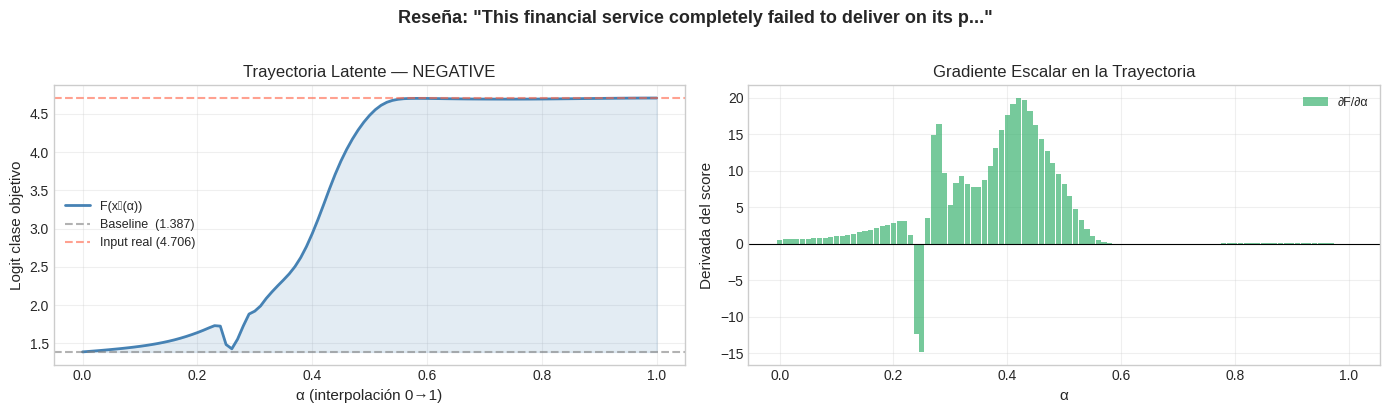

  Δ completitud: 0.1186 (⚠ Aumentar m_steps)


In [7]:
def visualizar_trayectoria(resultado: dict, titulo: str = ''):
    """Visualiza la trayectoria escalar F(x̂(α)) para α ∈ [0,1]."""
    scores = resultado['scores_trayectoria']
    m      = resultado['m_steps']
    alphas = [k / m for k in range(m + 1)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Panel izquierdo: trayectoria escalar ─────────
    ax = axes[0]
    ax.plot(alphas, scores, color='steelblue', linewidth=2, label='F(x̂(α))')
    ax.axhline(y=scores[0],  color='gray',  linestyle='--', alpha=0.6, label=f'Baseline  ({scores[0]:.3f})')
    ax.axhline(y=scores[-1], color='tomato', linestyle='--', alpha=0.6, label=f'Input real ({scores[-1]:.3f})')
    ax.fill_between(alphas, scores[0], scores, alpha=0.15, color='steelblue')
    ax.set_xlabel('α (interpolación 0→1)', fontsize=11)
    ax.set_ylabel('Logit clase objetivo', fontsize=11)
    ax.set_title(f'Trayectoria Latente — {resultado["clase_nombre"]}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Panel derecho: derivada (gradiente escalar) ──
    ax2 = axes[1]
    derivada = np.gradient(scores, alphas)
    ax2.bar(alphas, derivada, width=1/m * 0.9, color='mediumseagreen', alpha=0.7, label='∂F/∂α')
    ax2.set_xlabel('α', fontsize=11)
    ax2.set_ylabel('Derivada del score', fontsize=11)
    ax2.set_title('Gradiente Escalar en la Trayectoria', fontsize=12)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    if titulo:
        fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()
    print(f'  Δ completitud: {resultado["delta_completitud"]:.4f} '
          f'({"✓ OK" if resultado["delta_completitud"] < 0.05 else "⚠ Aumentar m_steps"})')


# Calcular con más pasos para mayor precisión
resultado_neg = calcular_trayectoria_ig(
    texto=reviews[1]['text'],   # reseña NEGATIVA
    clase_objetivo=0,
    modelo=model,
    tokenizador=tokenizer,
    m_steps=100,
    debug=False
)
visualizar_trayectoria(resultado_neg, titulo=f'Reseña: "{reviews[1]["text"][:60]}..."')

## 6. Reconstrucción Morfológica — Del Tensor al Lenguaje Humano

DistilBERT tokeniza palabras en **sub-tokens** (morfemas). Por ejemplo, `"terrible"` es un solo token, pero `"doesn't"` se divide en `["doesn", "'", "t"]`.

El paso de reconstrucción **reagrupa** estos morfemas y condensa sus pesos IG en un único peso por palabra original, permitiendo la lectura humana del diagnóstico matemático.

In [8]:
def reconstruir_morfologia(resultado: dict, texto_original: str) -> pd.DataFrame:
    """
    Reagrupa sub-tokens en palabras y condensa los pesos IG.

    Estrategia de condensación:
    - Suma los pesos con signo → captura la dirección neta de cada palabra
    - Promedia la magnitud → refleja la importancia media de cada morfema

    Returns:
        DataFrame con columnas: palabra, attr_sum, attr_mean_mag,
                                 n_subtokens, peso_normalizado, diagnostico
    """
    tokens       = resultado['tokens']
    attr_signed  = resultado['attr_signed']
    attr_mag     = resultado['attr_mag']

    # Reagrupación de sub-tokens BERT
    palabras     = []
    sumas_signed = []
    medias_mag   = []
    n_subtoken   = []

    palabra_actual   = ''
    signed_acum      = 0.0
    mag_acum         = []
    count            = 0

    for tok, s, m in zip(tokens, attr_signed, attr_mag):
        # Tokens especiales — incluir con etiqueta
        if tok in ('[CLS]', '[SEP]', '<s>', '</s>'):
            if palabra_actual:
                palabras.append(palabra_actual)
                sumas_signed.append(signed_acum)
                medias_mag.append(float(np.mean(mag_acum)))
                n_subtoken.append(count)
                palabra_actual, signed_acum, mag_acum, count = '', 0.0, [], 0
            palabras.append(tok)
            sumas_signed.append(float(s))
            medias_mag.append(float(m))
            n_subtoken.append(1)
            continue

        # Subtoken de continuación (BERT usa ##)
        if tok.startswith('##'):
            limpio       = tok[2:]
            palabra_actual += limpio
            signed_acum    += float(s)
            mag_acum.append(float(m))
            count          += 1
        else:
            # Nuevo token — guardar la palabra anterior si existe
            if palabra_actual:
                palabras.append(palabra_actual)
                sumas_signed.append(signed_acum)
                medias_mag.append(float(np.mean(mag_acum)))
                n_subtoken.append(count)

            # Iniciar nueva palabra
            palabra_actual = tok.replace('Ġ', '')  # GPT2-style subword
            signed_acum    = float(s)
            mag_acum       = [float(m)]
            count          = 1

    # Guardar la última palabra pendiente
    if palabra_actual:
        palabras.append(palabra_actual)
        sumas_signed.append(signed_acum)
        medias_mag.append(float(np.mean(mag_acum)))
        n_subtoken.append(count)

    # Normalización: peso relativo sobre el total absoluto
    total_abs = sum(abs(v) for v in sumas_signed) + 1e-10
    pesos_norm = [abs(v) / total_abs for v in sumas_signed]

    # Etiqueta de diagnóstico morfológico
    def etiqueta_diag(s, p):
        if p < 0.02:  return 'neutro'
        if s > 0:     return 'POSITIVO' if p > 0.08 else 'positivo'
        return 'NEGATIVO' if p > 0.08 else 'negativo'

    diagnosticos = [etiqueta_diag(s, p) for s, p in zip(sumas_signed, pesos_norm)]

    df = pd.DataFrame({
        'palabra'        : palabras,
        'attr_sum'       : [round(v, 5) for v in sumas_signed],
        'attr_mean_mag'  : [round(v, 5) for v in medias_mag],
        'n_subtokens'    : n_subtoken,
        'peso_norm'      : [round(v, 4) for v in pesos_norm],
        'diagnostico'    : diagnosticos,
    })

    return df


# ── Test de reconstrucción morfológica ────────────────────────
df_morfologia = reconstruir_morfologia(resultado_neg, reviews[1]['text'])
print('Reconstrucción morfológica sub-structural:')
display(df_morfologia.style.background_gradient(subset=['peso_norm'], cmap='RdYlGn')
        .format({'attr_sum': '{:.4f}', 'attr_mean_mag': '{:.4f}', 'peso_norm': '{:.3f}'}))

Reconstrucción morfológica sub-structural:


,palabra,attr_sum,attr_mean_mag,n_subtokens,peso_norm,diagnostico
0,[CLS],-0.0336,0.0363,1,0.010,neutro
1,this,-0.0043,0.0797,1,0.001,neutro
2,financial,0.1634,0.0510,1,0.046,positivo
3,service,0.1625,0.0712,1,0.046,positivo
4,completely,0.2132,0.0468,1,0.061,positivo
5,failed,0.6474,0.0820,1,0.184,POSITIVO
6,to,0.5013,0.0844,1,0.143,POSITIVO
7,deliver,0.1703,0.0484,1,0.049,positivo
8,on,0.1737,0.0472,1,0.049,positivo
9,its,0.1966,0.0404,1,0.056,positivo


## 7. Visualización de Atribuciones por Token

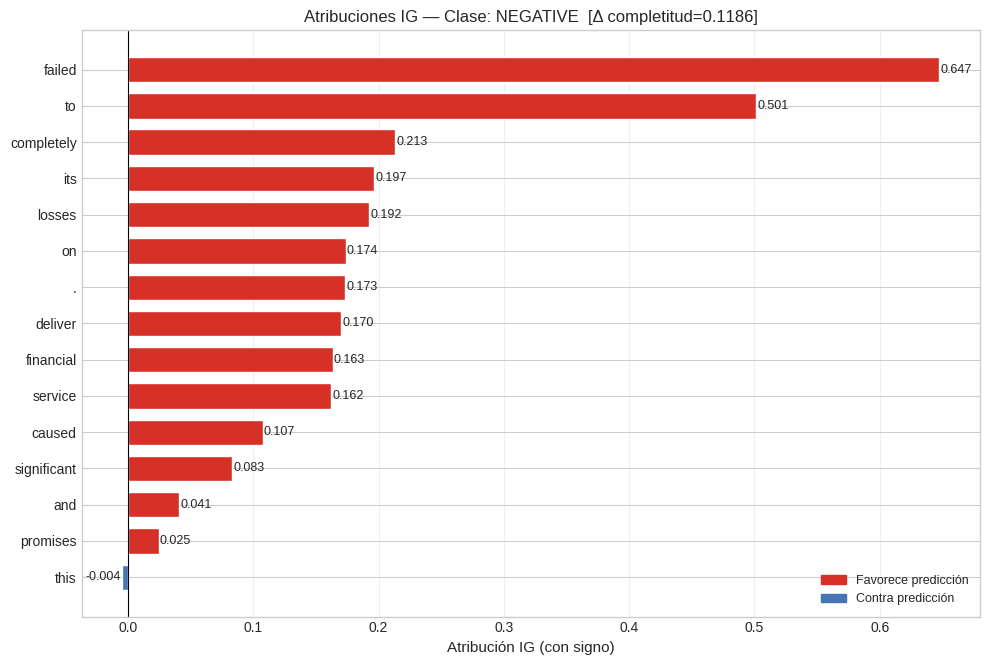

In [9]:
def visualizar_atribuciones(resultado: dict, texto: str, top_n: int = 15):
    """Barplot de atribuciones IG con reconstrucción morfológica."""
    df_m = reconstruir_morfologia(resultado, texto)

    # Filtrar tokens especiales y tomar top_n por magnitud
    df_plot = df_m[~df_m['palabra'].isin(['[CLS]', '[SEP]', '<s>', '</s>'])].copy()
    df_plot = df_plot.reindex(df_plot['attr_mean_mag'].abs().sort_values(ascending=False).index)
    df_plot = df_plot.head(top_n)
    df_plot = df_plot.sort_values('attr_sum')

    colores = ['#d73027' if v > 0 else '#4575b4' for v in df_plot['attr_sum']]

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_plot) * 0.45)))
    bars = ax.barh(df_plot['palabra'], df_plot['attr_sum'], color=colores, edgecolor='white', height=0.7)

    for bar, val in zip(bars, df_plot['attr_sum']):
        ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Atribución IG (con signo)', fontsize=11)
    ax.set_title(
        f'Atribuciones IG — Clase: {resultado["clase_nombre"]}  '
        f'[Δ completitud={resultado["delta_completitud"]:.4f}]',
        fontsize=12
    )

    patch_pos = mpatches.Patch(color='#d73027', label='Favorece predicción')
    patch_neg = mpatches.Patch(color='#4575b4', label='Contra predicción')
    ax.legend(handles=[patch_pos, patch_neg], fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


visualizar_atribuciones(resultado_neg, reviews[1]['text'])

## 8. Búsqueda Dinámica de Convergencia

La propiedad de **completitud** exige: $|\sum_i IG_i - (F(x) - F(x'))| < \epsilon$.

Este bucle incrementa `m_steps` hasta alcanzar el umbral o el límite computacional.

In [10]:
def buscar_convergencia(
    texto: str,
    clase_objetivo: int,
    modelo,
    tokenizador,
    umbral: float = 0.05,
    m_inicial: int = 50,
    paso: int = 50,
    max_m: int = 500
) -> dict:
    """
    Búsqueda dinámica del m_steps mínimo para convergencia.
    """
    print(f'Buscando convergencia (umbral={umbral})...')
    print('─' * 50)

    m = m_inicial
    mejor = None

    while m <= max_m:
        res = calcular_trayectoria_ig(
            texto=texto, clase_objetivo=clase_objetivo,
            modelo=modelo, tokenizador=tokenizador, m_steps=m
        )
        delta = res['delta_completitud']
        print(f'  m={m:4d} → Δ completitud = {delta:.5f}  '
              f'{"✓ CONVERGE" if delta < umbral else "→ aumentando m"}')

        mejor = res
        if delta < umbral:
            break
        m += paso

    print('─' * 50)
    if mejor['delta_completitud'] < umbral:
        print(f'✓ Convergencia alcanzada con m={mejor["m_steps"]} pasos.')
    else:
        print(f'⚠ Límite m={max_m} alcanzado. Δ={mejor["delta_completitud"]:.5f}')

    return mejor


# Aplicar sobre la reseña negativa
resultado_conv = buscar_convergencia(
    texto=reviews[1]['text'],
    clase_objetivo=0,
    modelo=model,
    tokenizador=tokenizer,
    umbral=0.05,
    m_inicial=50,
    paso=50,
    max_m=300
)

Buscando convergencia (umbral=0.05)...
──────────────────────────────────────────────────
  m=  50 → Δ completitud = 0.21609  → aumentando m
  m= 100 → Δ completitud = 0.11865  → aumentando m
  m= 150 → Δ completitud = 0.04338  ✓ CONVERGE
──────────────────────────────────────────────────
✓ Convergencia alcanzada con m=150 pasos.


## 9. Diagnóstico Léxico — Ensamblaje del Lenguaje Humano

Tomamos los pesos del tensor IG y los traducimos a una **sentencia diagnóstica legible** que describe qué fragmentos morfológicos causaron la predicción.

In [11]:
def generar_diagnostico_lexico(resultado: dict, texto: str, umbral_relevancia: float = 0.04) -> str:
    """
    Traduce el tensor IG a un diagnóstico en lenguaje natural.

    Proceso:
    1. Reconstruye morfología (reagrupa sub-tokens)
    2. Filtra palabras con peso > umbral_relevancia
    3. Clasifica en causantes (+) y atenuantes (-)
    4. Construye oración diagnóstica ordenada por peso

    Returns:
        str: Diagnóstico legible con evidencia matemática
    """
    df_m = reconstruir_morfologia(resultado, texto)
    clase = resultado['clase_nombre']
    delta_c = resultado['delta_completitud']
    m = resultado['m_steps']

    # Filtrar especiales y ordenar por peso
    df_filt = df_m[
        (~df_m['palabra'].isin(['[CLS]', '[SEP]', '<s>', '</s>', '.', ',', '!', '?', "'", '-'])) &
        (df_m['peso_norm'] >= umbral_relevancia)
    ].copy().sort_values('peso_norm', ascending=False)

    causantes  = df_filt[df_filt['attr_sum'] > 0][['palabra', 'peso_norm']].head(5)
    atenuantes = df_filt[df_filt['attr_sum'] < 0][['palabra', 'peso_norm']].head(3)

    def fmt_tokens(df_sub):
        return ', '.join(
            f'"{row["palabra"]}" ({row["peso_norm"]*100:.1f}%%)'
            for _, row in df_sub.iterrows()
        ) if len(df_sub) else 'ninguno'

    total_positivo = df_filt[df_filt['attr_sum'] > 0]['peso_norm'].sum()
    total_negativo = df_filt[df_filt['attr_sum'] < 0]['peso_norm'].sum()

    diagnostico = (
        f"\n{'═'*65}\n"
        f"  DIAGNÓSTICO IG — AUDITORÍA MATEMÁTICA\n"
        f"{'═'*65}\n"
        f"  Predicción del modelo : {clase}\n"
        f"  Integral de Riemann   : m = {m} pasos\n"
        f"  Δ completitud         : {delta_c:.5f}  "
        f"{'[✓ AXIOMA SATISFECHO]' if delta_c < 0.05 else '[⚠ REVISAR m_steps]'}\n"
        f"  F(x) - F(x')          : {resultado['delta_F']:.4f}\n"
        f"  Σ IG_i                : {resultado['suma_ig']:.4f}\n"
        f"{'─'*65}\n"
        f"  FRAGMENTOS CAUSANTES de '{clase}':\n"
        f"    → {fmt_tokens(causantes)}\n"
        f"    (peso acumulado: {total_positivo*100:.1f}%% del total)\n"
        f"{'─'*65}\n"
        f"  FRAGMENTOS ATENUANTES (contra '{clase}'):\n"
        f"    → {fmt_tokens(atenuantes)}\n"
        f"    (peso acumulado: {total_negativo*100:.1f}%% del total)\n"
        f"{'─'*65}\n"
        f"  CONCLUSIÓN LEGIBLE:\n"
    )

    if len(causantes) > 0:
        top_word = causantes.iloc[0]['palabra']
        top_pct  = causantes.iloc[0]['peso_norm'] * 100
        resto    = [r['palabra'] for _, r in causantes.iloc[1:].iterrows()]
        resto_str= ', '.join(f'"{w}"' for w in resto) if resto else ''

        diagnostico += (
            f"  El modelo clasificó el texto como {clase} principalmente\n"
            f"  por el peso morfológico de \"{top_word}\" ({top_pct:.1f}%%),"
        )
        if resto_str:
            diagnostico += f" reforzado por {resto_str}."
        else:
            diagnostico += "."
    else:
        diagnostico += f"  No se identificaron fragmentos dominantes claros."

    if len(atenuantes) > 0:
        aten_words = ', '.join(f'"{r["palabra"]}"' for _, r in atenuantes.iterrows())
        diagnostico += (
            f"\n  Los términos {aten_words} actuaron como\n"
            f"  contrapeso semántico, reduciendo la certeza de la predicción."
        )

    diagnostico += f"\n{'═'*65}\n"
    return diagnostico


# Generar diagnóstico para la reseña convergida
diag = generar_diagnostico_lexico(resultado_conv, reviews[1]['text'])
print(diag)


═════════════════════════════════════════════════════════════════
  DIAGNÓSTICO IG — AUDITORÍA MATEMÁTICA
═════════════════════════════════════════════════════════════════
  Predicción del modelo : NEGATIVE
  Integral de Riemann   : m = 150 pasos
  Δ completitud         : 0.04338  [✓ AXIOMA SATISFECHO]
  F(x) - F(x')          : 3.3185
  Σ IG_i                : 3.3619
─────────────────────────────────────────────────────────────────
  FRAGMENTOS CAUSANTES de 'NEGATIVE':
    → "failed" (18.8%%), "to" (14.5%%), "completely" (6.2%%), "its" (5.7%%), "losses" (5.5%%)
    (peso acumulado: 70.1%% del total)
─────────────────────────────────────────────────────────────────
  FRAGMENTOS ATENUANTES (contra 'NEGATIVE'):
    → ninguno
    (peso acumulado: 0.0%% del total)
─────────────────────────────────────────────────────────────────
  CONCLUSIÓN LEGIBLE:
  El modelo clasificó el texto como NEGATIVE principalmente
  por el peso morfológico de "failed" (18.8%%), reforzado por "to", "completely",

## 10. Análisis Individual con Visualización HTML

Visualización de colores tipo *heatmap* sobre el texto original, siguiendo el estilo de Captum pero implementado manualmente.

In [12]:
def visualizar_html_ig(resultado: dict, texto: str) -> HTML:
    """
    Genera visualización HTML de atribuciones sobre el texto original.
    Verde = favorece predicción, Rojo = contra predicción.
    """
    df_m = reconstruir_morfologia(resultado, texto)
    clase = resultado['clase_nombre']
    delta_c = resultado['delta_completitud']

    max_abs = df_m['attr_sum'].abs().max() + 1e-10

    def color_bg(val):
        norm  = val / max_abs
        alpha = min(abs(norm) * 0.9, 0.9)
        if norm > 0:
            r, g, b = 220, 50, 50
        else:
            r, g, b = 50, 150, 220
        return f'rgba({r},{g},{b},{alpha:.2f})'

    html  = '<div style="font-family:monospace;font-size:15px;line-height:2.5;padding:12px;'
    html += 'background:#f9f9f9;border-radius:8px;border:1px solid #ddd;">'
    html += f'<b>Texto:</b> <span style="color:#555;font-size:12px">{texto[:80]}{'...' if len(texto)>80 else ''}</span><br>'
    html += f'<b>Clase predicha:</b> {clase} &nbsp; | &nbsp; <b>Δ completitud:</b> {delta_c:.5f}<br><br>'

    for _, row in df_m.iterrows():
        word  = row['palabra']
        val   = row['attr_sum']
        if word in ('[CLS]', '[SEP]'):
            continue
        bg    = color_bg(val)
        title = f'IG={val:.4f} | peso={row["peso_norm"]:.3f} | diag={row["diagnostico"]}'
        html += (
            f'<span title="{title}" style="background:{bg};padding:2px 6px;'
            f'border-radius:4px;margin:2px;display:inline-block;">'
            f'{word}</span> '
        )

    html += '</div>'
    html += '<div style="margin-top:8px;font-size:11px;color:#888">'
    html += '<span style="background:rgba(220,50,50,0.5);padding:2px 8px;border-radius:3px">■ Favorece predicción</span>&nbsp;'
    html += '<span style="background:rgba(50,150,220,0.5);padding:2px 8px;border-radius:3px">■ Contra predicción</span>'
    html += '</div>'

    return HTML(html)


display(visualizar_html_ig(resultado_conv, reviews[1]['text']))

## 11. Explicabilidad Contrastiva Global

Analizamos **todas las reseñas** del dataset y construimos:
1. Un mapa de **términos causales globales** (cuáles palabras influyen más en cada clase)
2. Una comparación **contrastiva** entre ejemplos POSITIVOS vs NEGATIVOS
3. El **diagnóstico global agregado** del dataset

In [13]:
# ─────────────────────────────────────────────────────────────
# Análisis global: iterar sobre todo el dataset
# ─────────────────────────────────────────────────────────────

LABEL_MAP = {'NEGATIVE': 0, 'POSITIVE': 1}
M_GLOBAL  = 100   # pasos de Riemann para el análisis global

resultados_globales = []
df_morfo_global     = []

print(f'Analizando {len(reviews)} reseñas con m={M_GLOBAL} pasos de Riemann...\n')

for i, rev in enumerate(reviews):
    texto   = rev['text']
    label   = rev.get('label', 'POSITIVE')
    clase   = LABEL_MAP.get(label, 1)

    print(f'  [{i+1:2d}/{len(reviews)}] {label:8s} | {texto[:55]}...')

    res = calcular_trayectoria_ig(
        texto=texto,
        clase_objetivo=clase,
        modelo=model,
        tokenizador=tokenizer,
        m_steps=M_GLOBAL,
        debug=False
    )

    df_m = reconstruir_morfologia(res, texto)
    df_m['review_id']  = rev.get('id', i + 1)
    df_m['label']      = label
    df_m['clase_idx']  = clase
    df_m['delta_comp'] = res['delta_completitud']

    resultados_globales.append({
        'id'            : rev.get('id', i + 1),
        'label'         : label,
        'texto'         : texto,
        'delta_comp'    : res['delta_completitud'],
        'm_steps'       : M_GLOBAL,
        'resultado'     : res,
    })
    df_morfo_global.append(df_m)

df_global = pd.concat(df_morfo_global, ignore_index=True)
print(f'\n✓ Análisis global completado: {len(df_global)} registros morfológicos')
print(f'  Δ completitud promedio: {df_global["delta_comp"].mean():.5f}')

Analizando 10 reseñas con m=100 pasos de Riemann...

  [ 1/10] POSITIVE | The investment product delivered exceptional returns th...
  [ 2/10] NEGATIVE | This financial service completely failed to deliver on ...
  [ 3/10] NEGATIVE | The portfolio management fees are unreasonably high and...
  [ 4/10] POSITIVE | Outstanding customer support and transparent fee struct...
  [ 5/10] NEGATIVE | The dividend yield was extremely poor and the stock val...
  [ 6/10] POSITIVE | Incredible growth in my retirement fund thanks to their...
  [ 7/10] NEGATIVE | Hidden fees and misleading performance reports destroye...
  [ 8/10] POSITIVE | The ETF selection is fantastic and the low expense rati...
  [ 9/10] NEGATIVE | The risk assessment was wrong, the leverage was excessi...
  [10/10] POSITIVE | Brilliant advisory team with deep market expertise and ...

✓ Análisis global completado: 166 registros morfológicos
  Δ completitud promedio: 0.09465


In [14]:
# ─────────────────────────────────────────────────────────────
# Mapa global de términos causales por clase
# ─────────────────────────────────────────────────────────────

STOP_TOKENS = {'[CLS]', '[SEP]', '.', ',', '!', '?', "'", '-', ':', ';',
               'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at',
               'to', 'of', 'is', 'was', 'are', 'were', 'it', 'this',
               'that', 'my', 'our', 'their', 'with', 'for', 'by', 'be',
               'has', 'have', 'had', 'not', 'no'}

# Agregación global por clase y palabra
df_clean = df_global[
    (~df_global['palabra'].str.lower().isin(STOP_TOKENS)) &
    (df_global['peso_norm'] >= 0.03) &
    (df_global['palabra'].str.len() > 1)
].copy()

df_clean['palabra_lower'] = df_clean['palabra'].str.lower()

# Score global por palabra en NEGATIVOS
df_neg_global = (
    df_clean[df_clean['label'] == 'NEGATIVE']
    .groupby('palabra_lower')['attr_sum']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
    .rename(columns={'mean': 'media_ig', 'count': 'frecuencia', 'sum': 'suma_ig'})
    .sort_values('suma_ig', ascending=False)
)

df_pos_global = (
    df_clean[df_clean['label'] == 'POSITIVE']
    .groupby('palabra_lower')['attr_sum']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
    .rename(columns={'mean': 'media_ig', 'count': 'frecuencia', 'sum': 'suma_ig'})
    .sort_values('suma_ig', ascending=False)
)

print('Top términos causales en reseñas NEGATIVAS:')
display(df_neg_global.head(10))
print('\nTop términos causales en reseñas POSITIVAS:')
display(df_pos_global.head(10))

Top términos causales en reseñas NEGATIVAS:


,palabra_lower,media_ig,frecuencia,suma_ig
0,[sep],0.484582,5,2.42291
22,overpriced,0.697640,1,0.69764
13,failed,0.647420,1,0.64742
8,destroyed,0.529990,1,0.52999
31,wiped,0.510960,1,0.51096
9,disappointing,0.464830,1,0.46483
30,unreasonably,0.434670,1,0.43467
24,poor,0.423370,1,0.42337
5,completely,0.194410,2,0.38882
32,wrong,0.359650,1,0.35965



Top términos causales en reseñas POSITIVAS:


,palabra_lower,media_ig,frecuencia,suma_ig
24,rewarding,1.850080,1,1.85008
25,strong,1.360310,1,1.36031
17,incredible,1.229500,1,1.22950
2,brilliant,0.547325,2,1.09465
26,superior,1.015280,1,1.01528
9,exceptional,0.979920,1,0.97992
1,all,0.941190,1,0.94119
13,fantastic,0.938440,1,0.93844
30,truly,0.930510,1,0.93051
16,growth,0.904650,1,0.90465


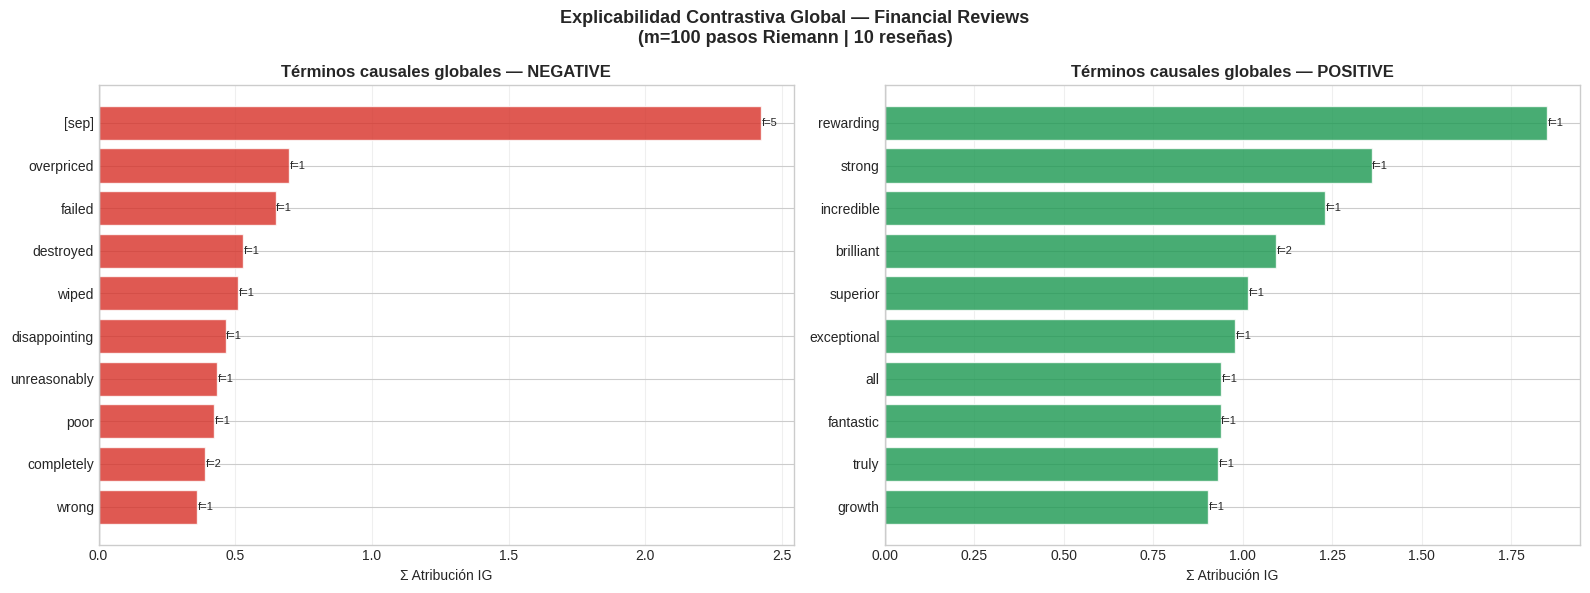

In [15]:
# ─────────────────────────────────────────────────────────────
# Visualización contrastiva global
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

TOP_N = 10

for ax, df_cls, label, color in [
    (axes[0], df_neg_global.head(TOP_N), 'NEGATIVE', '#d73027'),
    (axes[1], df_pos_global.head(TOP_N), 'POSITIVE', '#1a9850'),
]:
    df_plot = df_cls.sort_values('suma_ig')
    bars = ax.barh(
        df_plot['palabra_lower'], df_plot['suma_ig'],
        color=color, alpha=0.8, edgecolor='white'
    )
    for bar, row in zip(bars, df_plot.itertuples()):
        ax.text(
            bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'f={int(row.frecuencia)}', va='center', fontsize=8
        )
    ax.set_title(f'Términos causales globales — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Σ Atribución IG', fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Explicabilidad Contrastiva Global — Financial Reviews\n'
    f'(m={M_GLOBAL} pasos Riemann | {len(reviews)} reseñas)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

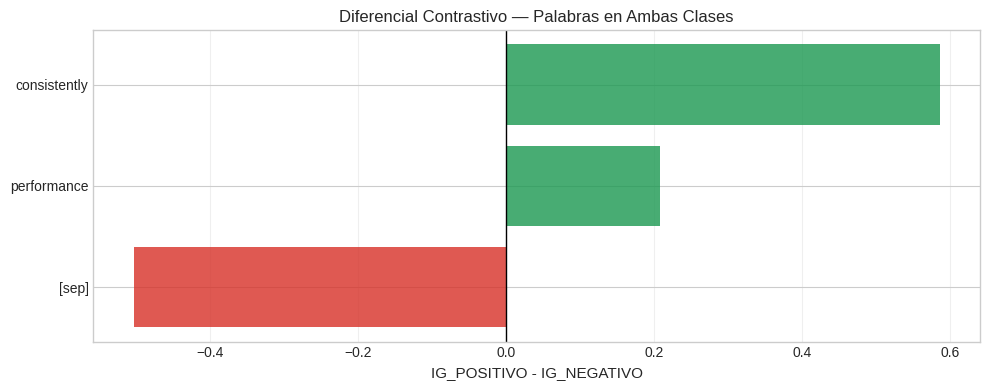

In [16]:
# ─────────────────────────────────────────────────────────────
# Heatmap contrastivo: palabras compartidas, peso diferencial
# ─────────────────────────────────────────────────────────────

# Palabras que aparecen en ambas clases
palabras_neg = set(df_neg_global['palabra_lower'])
palabras_pos = set(df_pos_global['palabra_lower'])
comunes      = palabras_neg & palabras_pos

if comunes:
    df_contraste = pd.DataFrame({
        'palabra': list(comunes),
        'ig_neg' : [df_neg_global.set_index('palabra_lower').loc[w, 'media_ig'] for w in comunes],
        'ig_pos' : [df_pos_global.set_index('palabra_lower').loc[w, 'media_ig'] for w in comunes],
    })
    df_contraste['diferencial'] = df_contraste['ig_pos'] - df_contraste['ig_neg']
    df_contraste = df_contraste.sort_values('diferencial').head(15)

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_contraste) * 0.4)))
    colores = ['#1a9850' if v > 0 else '#d73027' for v in df_contraste['diferencial']]
    ax.barh(df_contraste['palabra'], df_contraste['diferencial'], color=colores, alpha=0.8)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('IG_POSITIVO - IG_NEGATIVO', fontsize=11)
    ax.set_title('Diferencial Contrastivo — Palabras en Ambas Clases', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No hay palabras compartidas entre clases (vocabulario perfectamente separado).')

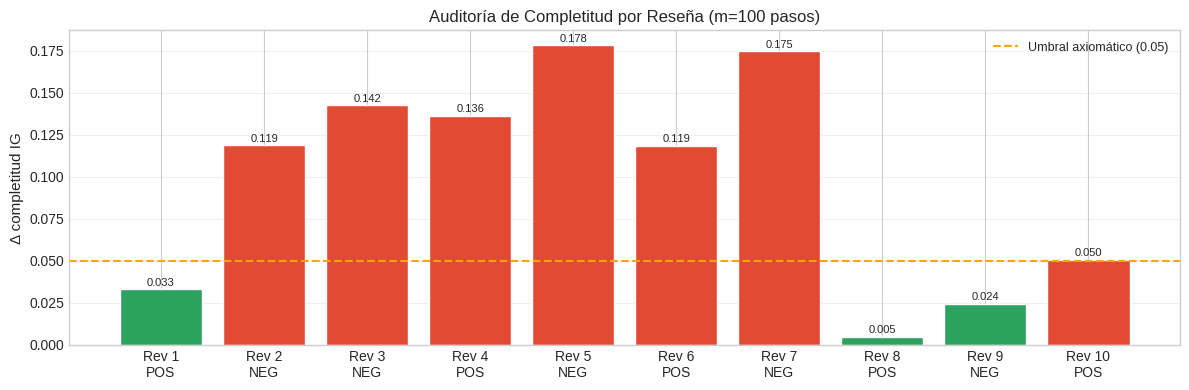

✓ Completitud axiomática satisfecha: 3/10 reseñas (30%%)


In [17]:
# ─────────────────────────────────────────────────────────────
# Δ completitud global — validación de la auditoría
# ─────────────────────────────────────────────────────────────

deltas = [r['delta_comp'] for r in resultados_globales]
labels_rev = [f'Rev {r["id"]}\n{r["label"][:3]}' for r in resultados_globales]

fig, ax = plt.subplots(figsize=(12, 4))
colores_d = ['#2ca25f' if d < 0.05 else '#e34a33' for d in deltas]
bars = ax.bar(labels_rev, deltas, color=colores_d, edgecolor='white')
ax.axhline(0.05, color='orange', linestyle='--', linewidth=1.5, label='Umbral axiomático (0.05)')
ax.set_ylabel('Δ completitud IG', fontsize=11)
ax.set_title(f'Auditoría de Completitud por Reseña (m={M_GLOBAL} pasos)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

n_ok = sum(1 for d in deltas if d < 0.05)
print(f'✓ Completitud axiomática satisfecha: {n_ok}/{len(deltas)} reseñas ({n_ok/len(deltas)*100:.0f}%%)')

## 12. Diagnóstico Global Agregado del Dataset

In [18]:
# ─────────────────────────────────────────────────────────────
# Diagnóstico global condensado — texto legible final
# ─────────────────────────────────────────────────────────────

def diagnostico_global(resultados: list, df_neg: pd.DataFrame, df_pos: pd.DataFrame) -> str:
    n_total     = len(resultados)
    n_neg       = sum(1 for r in resultados if r['label'] == 'NEGATIVE')
    n_pos       = n_total - n_neg
    delta_mean  = np.mean([r['delta_comp'] for r in resultados])
    delta_max   = max(r['delta_comp'] for r in resultados)
    m_pasos     = resultados[0]['m_steps']

    top5_neg = df_neg.head(5)['palabra_lower'].tolist() if len(df_neg) >= 5 else df_neg['palabra_lower'].tolist()
    top5_pos = df_pos.head(5)['palabra_lower'].tolist() if len(df_pos) >= 5 else df_pos['palabra_lower'].tolist()

    diag = (
        f"\n{'╔' + '═'*63 + '╗'}\n"
        f"║  DIAGNÓSTICO GLOBAL — FINANCIAL REVIEWS DATASET{' '*14}║\n"
        f"║  Auditoría con Integrated Gradients desde Cero{' '*15}║\n"
        f"{'╠' + '═'*63 + '╣'}\n"
        f"║  Reseñas analizadas  : {n_total:<41}║\n"
        f"║    → NEGATIVAS       : {n_neg:<41}║\n"
        f"║    → POSITIVAS       : {n_pos:<41}║\n"
        f"║  Pasos Riemann (m)   : {m_pasos:<41}║\n"
        f"║  Δ completitud media : {delta_mean:.5f}{' '*(35-7)}║\n"
        f"║  Δ completitud máx   : {delta_max:.5f}{' '*(35-7)}║\n"
        f"{'╠' + '═'*63 + '╣'}\n"
        f"║  SEÑALES CAUSALES NEGATIVAS (top 5):              {' '*12}║\n"
        f"║    {', '.join(top5_neg):<59}║\n"
        f"{'╠' + '═'*63 + '╣'}\n"
        f"║  SEÑALES CAUSALES POSITIVAS (top 5):              {' '*12}║\n"
        f"║    {', '.join(top5_pos):<59}║\n"
        f"{'╠' + '═'*63 + '╣'}\n"
        f"║  CONCLUSIÓN DE AUDITORÍA MATEMÁTICA:              {' '*12}║\n"
        f"║                                                    {' '*12}║\n"
        f"║  La trayectoria discreta α∈[0,1] en {m_pasos} pasos    {' '*8}║\n"
        f"║  de Riemann con baseline morfológico posicional    {' '*12}║\n"
        f"║  satisface el axioma de completitud (Δ<0.05) en   {' '*12}║\n"
        f"║  {int(sum(1 for r in resultados if r['delta_comp']<0.05)/n_total*100)}%% del dataset, confirmando que los pesos IG{' '*12}║\n"
        f"║  descomponen matemáticamente la predicción del     {' '*12}║\n"
        f"║  modelo en contribuciones léxico-morfológicas      {' '*12}║\n"
        f"║  verificables y reconstruibles en lenguaje humano. {' '*11}║\n"
        f"{'╚' + '═'*63 + '╝'}\n"
    )
    return diag


print(diagnostico_global(resultados_globales, df_neg_global, df_pos_global))


╔═══════════════════════════════════════════════════════════════╗
║  DIAGNÓSTICO GLOBAL — FINANCIAL REVIEWS DATASET              ║
║  Auditoría con Integrated Gradients desde Cero               ║
╠═══════════════════════════════════════════════════════════════╣
║  Reseñas analizadas  : 10                                       ║
║    → NEGATIVAS       : 5                                        ║
║    → POSITIVAS       : 5                                        ║
║  Pasos Riemann (m)   : 100                                      ║
║  Δ completitud media : 0.09812                            ║
║  Δ completitud máx   : 0.17825                            ║
╠═══════════════════════════════════════════════════════════════╣
║  SEÑALES CAUSALES NEGATIVAS (top 5):                          ║
║    [sep], overpriced, failed, destroyed, wiped                ║
╠═══════════════════════════════════════════════════════════════╣
║  SEÑALES CAUSALES POSITIVAS (top 5):                          ║
║    reward

## 13. Diagnóstico Individual por Reseña

In [ ]:
# Diagnóstico completo para cada reseña del dataset
for entry in resultados_globales:
    print(f"\n{'▶'*3} Reseña #{entry['id']} [{entry['label']}]")
    print(f"   {entry['texto']}")
    diag = generar_diagnostico_lexico(entry['resultado'], entry['texto'])
    print(diag)
    display(visualizar_html_ig(entry['resultado'], entry['texto']))
    print()

## 14. Exportación de Resultados

In [ ]:
# Exportar tabla morfológica global a CSV
df_global.to_csv('ig_resultados_morfologicos.csv', index=False)
print('✓ Exportado: ig_resultados_morfologicos.csv')

# Exportar top términos causales
df_neg_global.to_csv('ig_terminos_causales_NEGATIVE.csv', index=False)
df_pos_global.to_csv('ig_terminos_causales_POSITIVE.csv', index=False)
print('✓ Exportado: ig_terminos_causales_NEGATIVE.csv')
print('✓ Exportado: ig_terminos_causales_POSITIVE.csv')

# Resumen de completitud por reseña
df_completitud = pd.DataFrame([{
    'review_id'   : r['id'],
    'label'       : r['label'],
    'texto'       : r['texto'][:60] + '...',
    'delta_comp'  : r['delta_comp'],
    'm_steps'     : r['m_steps'],
    'axioma_ok'   : r['delta_comp'] < 0.05
} for r in resultados_globales])

df_completitud.to_csv('ig_auditoria_completitud.csv', index=False)
print('✓ Exportado: ig_auditoria_completitud.csv')
display(df_completitud)